# Flight Price prediction

This dataset contains flight booking information such as airline, source city, destination city, departure and arrival time, number of stops, class type, duration, days left before departure, and ticket price.  

The objective of this project is to analyze the factors affecting flight prices and compare multiple machine learning regression models to identify the best-performing model.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

#### Read csv file

Here we used Flight_price_prediction.csv file to train the machine learning model

In [4]:
df = pd.read_csv('Flight_Price_Prediction.csv',index_col = 0)
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


#### Define the datashape

This dataset contains flight booking details with 300,153 rows and 11 columns, including airline, route information, timing, travel class, journey duration, and ticket price. The dataset is used to build a machine learning model for predicting flight prices.


In [5]:
print('The dataset contains shape of',df.shape)

The dataset contains shape of (300153, 11)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [7]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


This dataset contains 300,153 flight records with 11 features and no missing values. It includes both categorical and numerical variables and is used to predict flight ticket prices.

In [8]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [9]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'SpiceJet'),
  Text(1, 0, 'AirAsia'),
  Text(2, 0, 'Vistara'),
  Text(3, 0, 'GO_FIRST'),
  Text(4, 0, 'Indigo'),
  Text(5, 0, 'Air_India')])

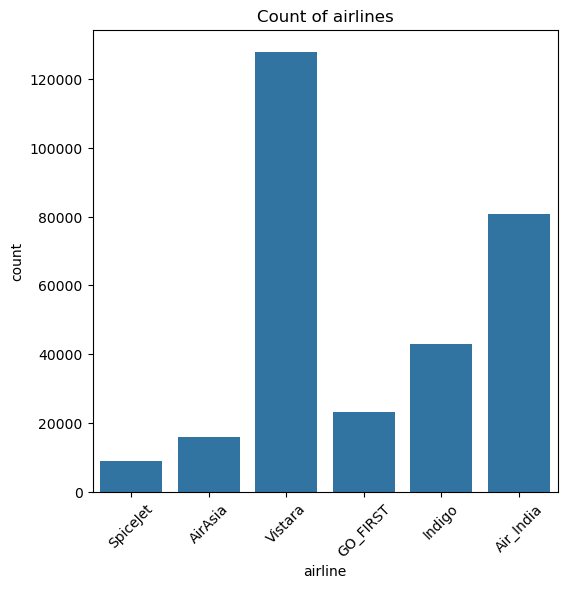

In [10]:
plt.figure(figsize=(6,6))
sns.countplot(x = df.airline,data=df)
plt.title('Count of airlines')
plt.xticks(rotation=45)

Number of flights: 1561


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'UK-706'),
  Text(1, 0, 'UK-772'),
  Text(2, 0, 'UK-720'),
  Text(3, 0, 'UK-836'),
  Text(4, 0, 'UK-822'),
  Text(5, 0, 'UK-828'),
  Text(6, 0, 'UK-874'),
  Text(7, 0, 'UK-832'),
  Text(8, 0, 'UK-826'),
  Text(9, 0, 'UK-860'),
  Text(10, 0, 'UK-876'),
  Text(11, 0, 'UK-878'),
  Text(12, 0, 'UK-838'),
  Text(13, 0, 'UK-830'),
  Text(14, 0, 'UK-870')])

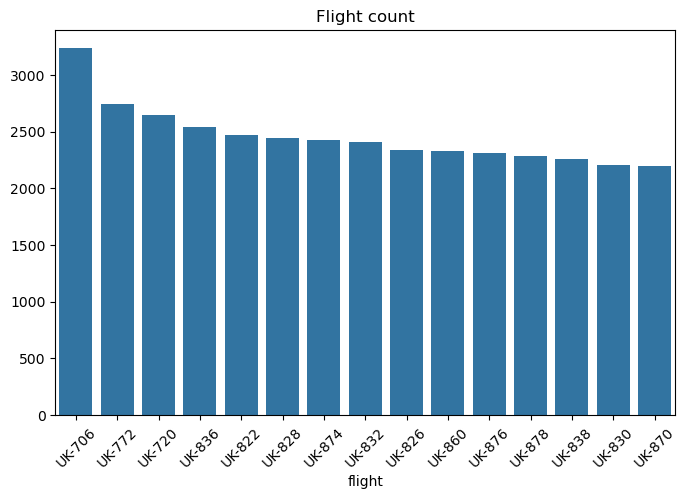

In [11]:
print('Number of flights:',df.flight.nunique())
flight_count = df.flight.value_counts().head(15)
plt.figure(figsize=(8,5))
sns.barplot(x = flight_count.index,y = flight_count.values)
plt.title('Flight count')
plt.xticks(rotation=45)

In [12]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

<Axes: xlabel='source_city', ylabel='count'>

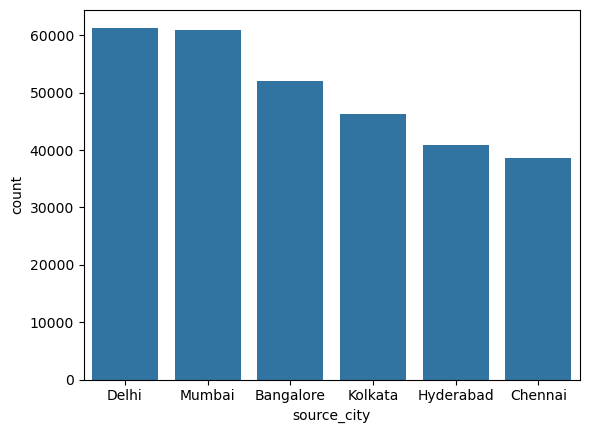

In [13]:
source_city = df['source_city']
sns.countplot(x = source_city)

In [14]:
flight_count = (df.groupby(['source_city','destination_city']).size().reset_index(name='Flight_count').sort_values(by = 'Flight_count',ascending = False))
flight_count.head(10)

,source_city,destination_city,Flight_count
14,Delhi,Mumbai,15289
27,Mumbai,Delhi,14809
10,Delhi,Bangalore,14012
1,Bangalore,Delhi,13756
4,Bangalore,Mumbai,12939
25,Mumbai,Bangalore,12885
29,Mumbai,Kolkata,12602
13,Delhi,Kolkata,11934
24,Kolkata,Mumbai,11467
11,Delhi,Chennai,10780


airline
AirAsia      1105
Air_India    1526
GO_FIRST     1105
Indigo       1105
SpiceJet     1106
Vistara      1714
Name: price, dtype: int64


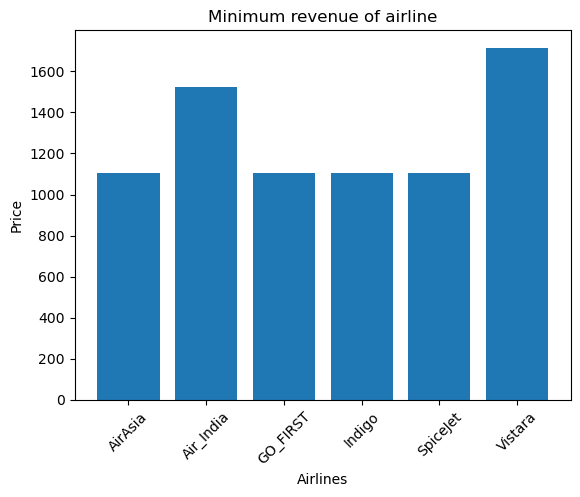

In [15]:
min_airline_revenue = df.groupby('airline')['price'].min()
plt.bar(min_airline_revenue.index,min_airline_revenue.values)
plt.xlabel('Airlines')
plt.ylabel('Price')
plt.title('Minimum revenue of airline')
plt.xticks(rotation = 45)
print(min_airline_revenue)

airline
AirAsia       31917
Air_India     90970
GO_FIRST      32803
Indigo        31952
SpiceJet      34158
Vistara      123071
Name: price, dtype: int64


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'AirAsia'),
  Text(1, 0, 'Air_India'),
  Text(2, 0, 'GO_FIRST'),
  Text(3, 0, 'Indigo'),
  Text(4, 0, 'SpiceJet'),
  Text(5, 0, 'Vistara')])

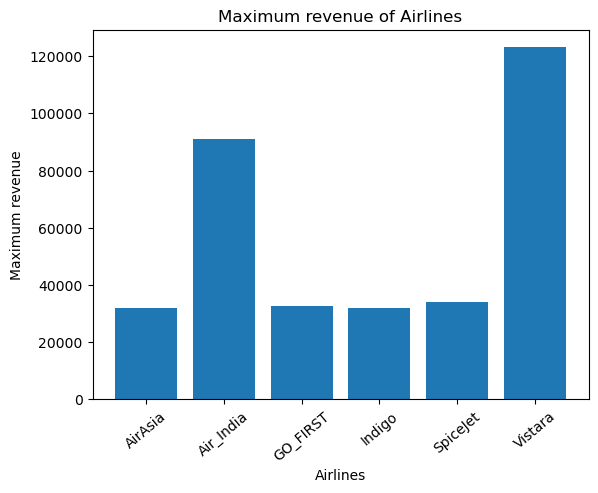

In [16]:
max_revenue = df.groupby('airline')['price'].max()
print(max_revenue)
plt.bar(max_revenue.index,max_revenue.values)
plt.xlabel('Airlines')
plt.ylabel('Maximum revenue')
plt.title('Maximum revenue of Airlines')
plt.xticks(rotation = 40)

In [17]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='count'>

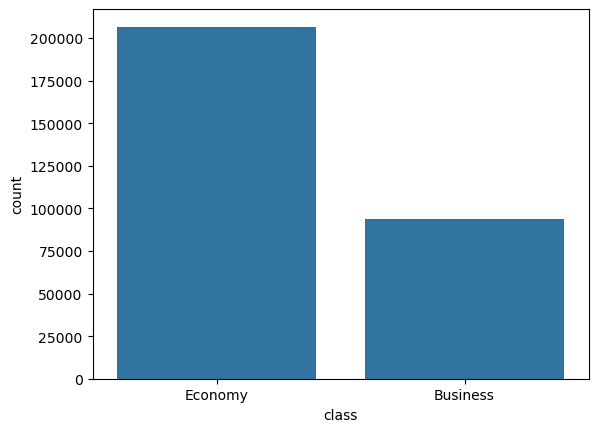

In [18]:
sns.countplot(x = df['class'])

In [19]:
num_col = df.select_dtypes(include='number')

<Axes: >

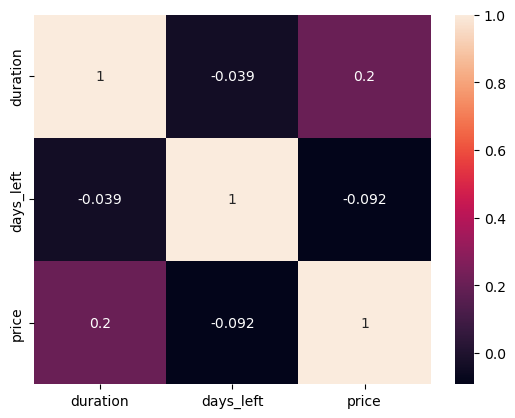

In [20]:
corr = num_col.corr()
sns.heatmap(corr,annot = True)

### Train the model using Machine learning model

In [21]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error,r2_score

In [22]:
models = [
    ('LinearRegression' , LinearRegression()),
    ('Lasso' , Lasso()),
    ('Ridge' , Ridge()),
    ('DecisionTree' , DecisionTreeRegressor(random_state = 42)),
    ('RandomForest' , RandomForestRegressor(random_state = 42)),
    ('Gradientboost' , GradientBoostingRegressor(random_state = 42)),
    ('xgboost' , XGBRegressor()),
    ('Lightgbm' , LGBMRegressor())
]

In [23]:
cat_col = df.select_dtypes(include = 'object').columns
cat_col

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

In [24]:
encoder = LabelEncoder()
for columns in cat_col:
    df[columns] = encoder.fit_transform(df[columns])

In [25]:
scaler = StandardScaler()
df['duration'] = scaler.fit_transform(df[['duration']])
df['price'] = scaler.fit_transform(df[['price']])

In [26]:
X = df.drop(['flight','price'] , axis = 1)
y = df.price
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

 Random Forest performed best among all tested models, so it is chosen as the final model.


In [27]:
for name , model in models:
# pipline the steps in order
    pipeline = Pipeline([('model',model)])
# fit the model with X_train , y_train
    pipeline.fit(X_train,y_train)
# predict the values
    y_pred = pipeline.predict(X_test)
# check the r2 score of the each model
    MAE = mean_absolute_error(y_test,y_pred)
# print the each model r2_score
    print('Model Name:',name)
    print('Mean absolute error' , MAE)
    print()

Model Name: LinearRegression
Mean absolute error 0.20376464776639264

Model Name: Lasso
Mean absolute error 0.8705768907231384

Model Name: Ridge
Mean absolute error 0.20376644624531493

Model Name: DecisionTree
Mean absolute error 0.05195261913620001

Model Name: RandomForest
Mean absolute error 0.048075774140696394

Model Name: Gradientboost
Mean absolute error 0.13039520127496945

Model Name: xgboost
Mean absolute error 0.0896800155779769



  File "D:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pid, t

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 340
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features: 9
[LightGBM] [Info] Start training from score -0.000048
Model Name: Lightgbm
Mean absolute error 0.1044534835855446



- Models were compared using evaluation metrics like R² Score / RMSE
- Random Forest performed the best